# Análise dos Resultados

Requer `previsoes_consolidadas.csv` gerado por `02_modelos.R` (M0, M1, M2, painel alinhado).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from arch.bootstrap import MCS
from datetime import datetime

CAMINHO = "./data/"


In [2]:
# ── Carrega dados ────────────────────────────────────────────────
df_acoes        = pd.read_csv(CAMINHO + "acoes_elegiveis.csv")
df_trends       = pd.read_csv(CAMINHO + "google_trends_svi.csv",     parse_dates=["semana"])
df_final        = pd.read_csv(CAMINHO + "base_final_tcc.csv",        parse_dates=["semana"])

df_previsoes    = pd.read_csv(CAMINHO + "previsoes_consolidadas.csv", parse_dates=["semana"])
df_resumo_params = pd.read_csv(CAMINHO + "resumo_parametros.csv").set_index("ticker_b3")

# ── Proporção de zeros no SVI ─────────────────────────────────────
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
df_resumo_params["svi_zeros_pct"] = zeros_pct.reindex(df_resumo_params.index)
tickers_erro_m2 = df_previsoes[(df_previsoes["status_m2"] != "ok") | (df_previsoes['rv_pred_m2'] == np.inf)]["ticker_b3"].unique()

In [3]:
df_previsoes[(df_previsoes["status_m2"] != "ok") | (df_previsoes['rv_pred_m2'] == np.inf)]["ticker_b3"].unique()

<StringArray>
[ 'AFLT3',  'AHEB3',  'ALUP3',  'ALUP4',  'AXIA3',  'AXIA6',  'BALM4',
  'BDLL4',  'BEES4',  'BNBR3',  'BPAC5',  'BRSR3',  'CEDO3',  'CEEB3',
  'CGAS5',  'CGRA4',  'CLSC4',  'COCE5',  'DEXP4',  'DOHL4', 'EQMA3B',
  'EQPA3',  'FESA3',  'GEPA4',  'GGBR3',  'GSHP3',  'ISAE3',  'ISAE4',
  'LUXM4',  'MBRF3',  'PATI4',  'PEAB3',  'PNVL3', 'PPLA11',  'REDE3',
  'RPAD3',  'RPAD6',  'RSUL4',  'TKNO4',  'UNIP3',  'WHRL3',  'WHRL4']
Length: 42, dtype: str

# Testes qlike e MCS

In [4]:
# ── QLIKE loss ───────────────────────────────────────────────────
def qlike(rv, pred):
    """QLIKE: rv/pred - log(rv/pred) - 1. NaN onde rv ou pred <= 0."""
    ok = (rv > 0) & (pred > 0)
    r  = np.where(ok, rv / pred, np.nan)
    return np.where(ok, r - np.log(r) - 1, np.nan)

NOMES_MODELOS = {
    "qlike_m0": "M0_RW",
    "qlike_m1": "M1_GARCH",
    "qlike_m2": "M2_GARCHX",
}

# Piso minimo para previsoes GARCH/EGARCH. Valores abaixo (ou inf/NaN)
# indicam falha numerica do ajuste: o log-variance do EGARCH pode driftar
# sem ser capturado pelo status do hessiano, gerando QLIKE astronomico
# que quebra o MCS. Aplica-se apenas a M1/M2; M0 (RW) so propaga RV
# observada, entao valores pequenos sao dado real, nao falha de modelo.
PRED_MIN = 1e-8

def filtrar_tickers(df, zeros_pct, threshold_zeros=None, remove_singular=True):
    """Filtra tickers para a comparacao de modelos.

    Dois conjuntos de tickers problematicos sao identificados:
      * patologicos : algum rv_pred_m1/m2 nao-finito ou < PRED_MIN
        (falha numerica do GARCH/EGARCH) -> SEMPRE descartados.
      * singulares  : status_m2 != 'ok' (hessiana singular / warning do
        rugarch) -> descartados apenas se remove_singular=True.

    Retorna (df_filtrado, info_dict com contagens para relatorio).
    """
    pred_cols = ["rv_pred_m1", "rv_pred_m2"]
    preds = df[pred_cols].to_numpy()
    rows_ok = np.all(np.isfinite(preds) & (preds >= PRED_MIN), axis=1)
    tickers_pat  = set(df.loc[~rows_ok, "ticker_b3"].unique())
    tickers_sing = set(df.loc[df["status_m2"] != "ok", "ticker_b3"].unique())
    tickers_erro = tickers_pat | tickers_sing

    info = {
        "n_total":     df["ticker_b3"].nunique(),
        "n_patologic": len(tickers_pat),
        "n_singular":  len(tickers_sing),
        "n_erros":     len(tickers_erro),
    }

    # Sempre descarta tickers com previsoes patologicas
    df = df[~df["ticker_b3"].isin(tickers_pat)]

    if threshold_zeros is not None:
        ok = zeros_pct[zeros_pct < threshold_zeros].index
        df = df[df["ticker_b3"].isin(ok)]
        info["n_apos_zeros"]    = df["ticker_b3"].nunique()
        info["erros_apos_zeros"] = df[df["ticker_b3"].isin(tickers_erro)]["ticker_b3"].nunique()

    if remove_singular:
        df = df[~df["ticker_b3"].isin(tickers_sing)]

    info["n_final"] = df["ticker_b3"].nunique()
    return df, info


def calcular_losses(df):
    """Calcula QLIKE por modelo. Retorna (losses sem NaN, n_descartadas)."""
    df = df.copy()
    for m in ["m0", "m1", "m2"]:
        df[f"qlike_{m}"] = qlike(df["rv"].values, df[f"rv_pred_{m}"].values)

    losses = (
        df[list(NOMES_MODELOS)]
        .dropna()
        .rename(columns=NOMES_MODELOS)
        .reset_index(drop=True)
    )
    return losses, len(df) - len(losses)


def rodar_mcs(losses, alpha=0.10):
    """Model Confidence Set. Retorna (mcs_obj, df_pvalores)."""
    mcs = MCS(losses, size=alpha, block_size=5, reps=1000, seed=42)
    mcs.compute()
    df_p = (
        mcs.pvalues
        .rename(columns={"Pvalue": "p_valor"})
        .assign(no_conjunto=lambda d: d["p_valor"] >= alpha)
        .sort_values("p_valor", ascending=False)
    )
    return mcs, df_p


def resumo_gamma(df_resumo, tickers):
    """Conta tickers com gamma significativo em >=50% das janelas."""
    df    = df_resumo.loc[df_resumo.index.isin(tickers)]
    n_sig = int((df["pct_signif_5pct"] >= 50).sum())
    top5  = df["pct_signif_5pct"].sort_values(ascending=False).head(5)
    return n_sig, top5


def gerar_bloco(df_prev, df_resumo, zeros_pct,
                threshold_zeros=None, remove_singular=True, label=""):
    """Gera bloco de texto com diagnostico para um cenario de filtragem."""
    df, info       = filtrar_tickers(df_prev, zeros_pct, threshold_zeros, remove_singular)
    tickers_finais = set(df["ticker_b3"].unique())
    losses, n_desc = calcular_losses(df)
    mcs, df_pval   = rodar_mcs(losses)
    n_sig, top5    = resumo_gamma(df_resumo, tickers_finais)

    # Formata texto
    sep = "═" * 60
    L   = [f"\n{sep}", f"  {label}", sep]

    L.append(f"  Tickers em df_previsoes              : {info['n_total']}")
    L.append(f"  Com erro (M2)                        : {info['n_erros']}")
    if threshold_zeros is not None:
        pct = int(threshold_zeros * 100)
        L.append(f"  Apos filtro zeros >={pct}%              : {info['n_apos_zeros']}  ({info['erros_apos_zeros']} com erro)")
    L.append(f"  Na comparacao final                  : {info['n_final']}")
    L.append(f"  Obs. OOS usadas / descartadas        : {len(losses)} / {n_desc}")

    L.append("\n  QLIKE medio:")
    for col in losses.columns:
        L.append(f"    {col:<15}: {losses[col].mean():.6f}")

    L.append("\n  MCS (alpha=10%):")
    for line in df_pval.to_string().split("\n"):
        L.append(f"    {line}")
    L.append(f"\n  Conjunto de confianca : {list(mcs.included)}")
    L.append(f"  Excluidos             : {list(mcs.excluded)}")

    L.append(f"\n  gamma significativo em >=50% das janelas:")
    L.append(f"    {n_sig}/{info['n_final']} tickers")
    L.append("\n  Top 5 por % de janelas significativas (gamma):")
    L.append(top5.to_string())

    return "\n".join(L) + "\n"

In [5]:
# ── Gera diagnostico ─────────────────────────────────────────────
cenarios = [
    # (threshold, remove_singular_matrix, label)
    (None, False, "1. Considerando todos os ativo"),
    (None, True, "1.b. Considerando todos os ativo, filtrando erro hessiana"),
    (0.70, True,  "2. Filtro >=70%"),
    (0.50, True,  "3. Filtro >=50%"),
]

TXT = "/diagnostico_filtros.txt"
with open(f"{CAMINHO}{TXT}", "w", encoding="utf-8") as f:
    f.write("Diagnostico - comparacao de cenarios\n")
    f.write(f"Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    for threshold, remove_sing, label in cenarios:
        bloco = gerar_bloco(df_previsoes, df_resumo_params, zeros_pct,
                            threshold, remove_sing, label)
        f.write(bloco)

print(f"✓ Salvo em {TXT}")

✓ Salvo em /diagnostico_filtros.txt


## Estimativas GARCH/GARCH-X e o δ do ASVI (GARCH-X vs eGARCH-X)

Anexa ao `diagnostico_filtros.txt` (1) os coeficientes médios estimados dos quatro
modelos GARCH-family (M1 eGARCH, M2 eGARCH-X, M3 GARCH, M4 GARCH-X) e (2) o p-valor
do coeficiente δ do ASVI no **GARCH-X (M4)** vs. **eGARCH-X (M2)**, para avaliar se
ele sobe ao trocar o modelo simétrico pelo assimétrico. Ver a nota metodológica
sobre a censura de δ≥0 no sGARCH-X, que torna o p-valor do M4 não comparável
diretamente ao do M2.

In [ ]:
# ── Estimativas GARCH/GARCH-X + delta (ASVI): GARCH-X vs eGARCH-X ────────────
# Anexa duas secoes ao diagnostico_filtros.txt:
#   (1) coeficientes medios estimados de M1-M4 (GARCH, GARCH-X, eGARCH, eGARCH-X)
#   (2) p-valor do delta do ASVI no GARCH-X (M4) vs eGARCH-X (M2)
ARQ_DIAG = CAMINHO + "diagnostico_filtros.txt"

def _media_ok(status_col, mapa):
    """Media dos coeficientes nas janelas com ajuste 'ok' do modelo."""
    sub = df_previsoes[df_previsoes[status_col] == "ok"]
    linha = {"n_janelas": len(sub)}
    for nome, col in mapa.items():
        linha[nome] = sub[col].mean() if col in df_previsoes.columns else np.nan
    return linha

# (1) Estimativas medias dos 4 modelos (NaN = parametro nao existe naquele modelo)
tab_est = pd.DataFrame({
    "M3 GARCH":    _media_ok("status_m3", {"omega": "omega_m3", "alpha": "alpha_m3", "beta": "beta_m3"}),
    "M4 GARCH-X":  _media_ok("status_m4", {"alpha": "alpha_m4", "beta": "beta_m4", "delta_SVI": "delta_m4", "pval_delta": "delta_pval_m4"}),
    "M1 eGARCH":   _media_ok("status_m1", {"omega": "omega", "alpha": "alpha", "beta": "beta", "leverage_g1": "leverage_m1"}),
    "M2 eGARCH-X": _media_ok("status_m2", {"alpha": "alpha_m2", "beta": "beta_m2", "leverage_g1": "leverage_m2", "delta_SVI": "gamma", "pval_delta": "gamma_pval"}),
}).T
tab_est["persistencia"] = tab_est["alpha"] + tab_est["beta"]
tab_est = tab_est[["n_janelas", "omega", "alpha", "beta", "persistencia", "leverage_g1", "delta_SVI", "pval_delta"]]

# (2) delta (ASVI) pooled em TODAS as janelas OOS (na.rm), como no 02_modelos.R
def _resumo_delta(coef, pval):
    c, p = df_previsoes[coef], df_previsoes[pval]
    return {
        "n_janelas":      int(p.notna().sum()),
        "delta_medio":    c.mean(),
        "delta_mediano":  c.median(),
        "pval_medio":     p.mean(),
        "pval_mediano":   p.median(),
        "signif_5pct_%":  (p < 0.05).sum() / p.notna().sum() * 100,
        "signif_10pct_%": (p < 0.10).sum() / p.notna().sum() * 100,
    }
tab_delta = pd.DataFrame({
    "GARCH-X (M4, simetrico)":    _resumo_delta("delta_m4", "delta_pval_m4"),
    "eGARCH-X (M2, assimetrico)": _resumo_delta("gamma", "gamma_pval"),
}).T

# % de tickers com SVI signif. (5%) na MAIORIA (>=50%) das janelas
_g = df_resumo_params["pct_signif_garch_5pct"]
_e = df_resumo_params["pct_signif_egarch_5pct"]
pct_maioria = pd.Series({
    "GARCH-X (M4)":  (_g >= 50).sum() / _g.notna().sum() * 100,
    "eGARCH-X (M2)": (_e >= 50).sum() / _e.notna().sum() * 100,
})

# fracao do delta do GARCH-X presa no limite >=0 do rugarch (variancia em nivel)
delta4 = df_previsoes["delta_m4"].dropna()
pct_censura = ((delta4 >= 0) & (delta4 < 1e-6)).mean() * 100

sep = "=" * 64
bloco = "\n".join([
    "", sep,
    "  ESTIMATIVAS MEDIAS DOS MODELOS GARCH-FAMILY",
    "  (media das janelas com ajuste status='ok'; NaN = parametro ausente no modelo)",
    sep,
    tab_est.round(4).to_string(),
    "", sep,
    "  delta (ASVI): p-valor no GARCH-X (M4) vs eGARCH-X (M2)",
    sep,
    tab_delta.round(4).to_string(),
    "",
    "  % de tickers com SVI signif. (5%) na MAIORIA (>=50%) das janelas:",
    pct_maioria.round(1).to_string(),
]) + "\n"

with open(ARQ_DIAG, "a", encoding="utf-8") as f:
    f.write(bloco)

print(bloco)


  ESTIMATIVAS MEDIAS DOS MODELOS GARCH-FAMILY
  (media das janelas com ajuste status='ok'; NaN = parametro ausente no modelo)
             n_janelas   omega   alpha    beta  persistencia  leverage_g1  delta_SVI  pval_delta
M3 GARCH       30900.0  2.7801  0.0695  0.8772        0.9466          NaN        NaN         NaN
M4 GARCH-X     30900.0     NaN  0.0706  0.8760        0.9466          NaN     0.4233      0.9531
M1 eGARCH      30872.0  1.6241  0.0387  0.5046        0.5432       0.1225        NaN         NaN
M2 eGARCH-X    30660.0     NaN  0.0389  0.3645        0.4034       0.1377    -0.2641      0.2668

  delta (ASVI): p-valor no GARCH-X (M4) vs eGARCH-X (M2)
                            n_janelas  delta_medio  delta_mediano  pval_medio  pval_mediano  signif_5pct_%  signif_10pct_%
GARCH-X (M4, simetrico)       30900.0       0.4233         0.0000      0.9531        1.0000         1.5340          2.0388
eGARCH-X (M2, assimetrico)    30886.0      -0.2839        -0.0123      0.2721       

In [7]:
# ── Salvar QLIKE por ticker e MCS (todos os ativos) ──────────────
# Filtra apenas tickers com erro de singular matrix no M2
df_ok, info = filtrar_tickers(df_previsoes, zeros_pct,
                              threshold_zeros=None, remove_singular=False)

# Calcula QLIKE por observacao
df_ok = df_ok.copy()
for m in ["m0", "m1", "m2"]:
    df_ok[f"qlike_{m}"] = qlike(df_ok["rv"].values, df_ok[f"rv_pred_{m}"].values)

# QLIKE medio por ticker
df_qlike = (
    df_ok.groupby("ticker_b3")[list(NOMES_MODELOS)]
    .mean()
    .rename(columns=NOMES_MODELOS)
)

# MCS no agregado (pooled)
losses, n_desc = calcular_losses(df_ok)
mcs, df_mcs_principal = rodar_mcs(losses, alpha=0.10)

# Salva CSVs
df_qlike.to_csv(CAMINHO + "qlike_por_ticker.csv")
df_mcs_principal.to_csv(CAMINHO + "mcs_resultado.csv")

## Diagnósticos dos Resíduos Padronizados

Resultados de Ljung-Box em $z_t$ e $z_t^2$, Jarque-Bera e Q-Q plot para o
Top 5 de tickers ranqueados por `pct_signif_5pct` (significância de γ no M2).

In [8]:
df_diag = pd.read_csv(CAMINHO + "diagnosticos_residuos.csv")
df_z    = pd.read_csv(CAMINHO + "residuos_padronizados.csv")

tab = (
    df_diag
    .assign(ticker_b3=lambda d: pd.Categorical(d["ticker_b3"], ordered=True))
    .sort_values(["ticker_b3", "modelo"])
    [["ticker_b3", "modelo", "assimetria", "curtose",
      "lb_z_pvalor", "lb_z2_pvalor", "jb_pvalor"]]
    .round(4)
)
print(tab.to_string(index=False))

ticker_b3 modelo  assimetria  curtose  lb_z_pvalor  lb_z2_pvalor  jb_pvalor
    AALR3     m1     -1.3867   8.5827       0.4915        0.9757     0.0000
    AALR3     m2     -0.7550   6.6044       0.6206        0.9486     0.0000
    AALR3     m3     -1.5174   9.6140       0.4432        0.9067     0.0000
    AALR3     m4     -1.5180   9.6164       0.4431        0.9068     0.0000
    ABCB4     m1      0.5867   3.4703       0.8456        0.9672     0.0056
    ABCB4     m2      0.4729   2.8864       0.8034        0.9392     0.0524
    ABCB4     m3      0.5661   3.4237       0.8484        0.9587     0.0087
    ABCB4     m4      0.5662   3.4239       0.8484        0.9587     0.0086
    ABEV3     m1      0.5146   4.5208       0.5152        0.6692     0.0000
    ABEV3     m2      0.2913   3.6881       0.3672        0.5633     0.0712
    ABEV3     m3      0.4301   4.9365       0.5235        0.4634     0.0000
    ABEV3     m4      0.4313   4.9372       0.5241        0.4607     0.0000
    AERI3   

# Outras coisas

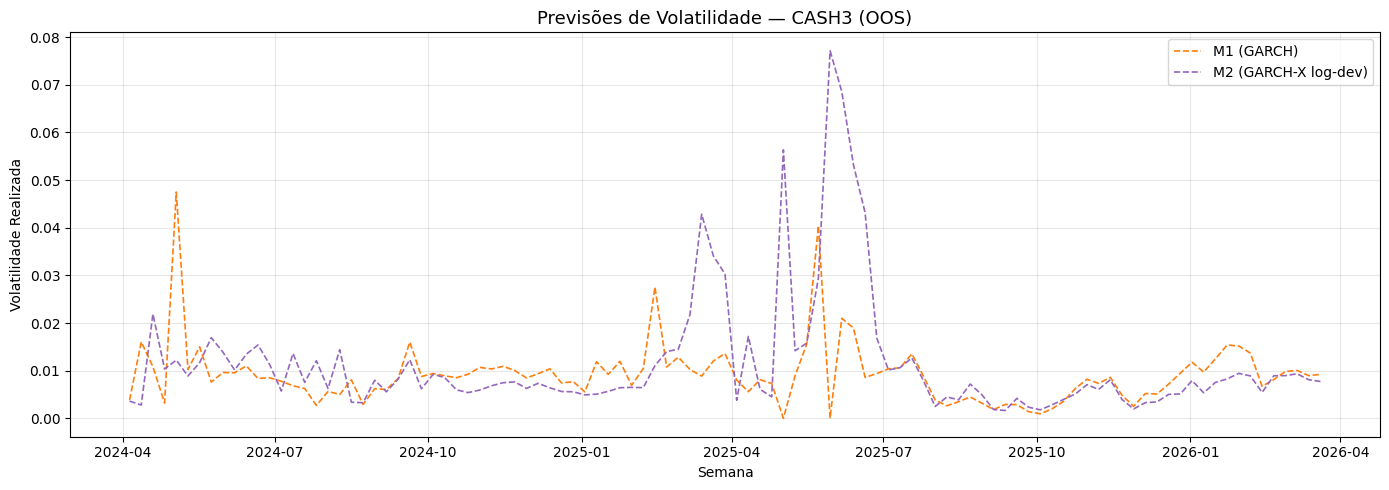

In [9]:
# ── Gráfico comparando as previsões ────────────────────────────────────────────────
TICKER = "CASH3" 

df_graf = (
    df_previsoes
    .query("ticker_b3 == @TICKER")
    .sort_values("semana")
)

fig, ax = plt.subplots(figsize=(14, 5))

#ax.plot(df_graf["semana"], df_graf["rv"],         label="RV Realizada", color="black",   linewidth=1.0, zorder=5)
#ax.plot(df_graf["semana"], df_graf["rv_pred_m0"], label="M0 (RW)",      color="#aec7e8", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m1"], label="M1 (GARCH)",   color="#ff7f0e", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m2"], label="M2 (GARCH-X log-dev)", color="#9467bd", linewidth=1.2, linestyle="--")

ax.set_title(f"Previsões de Volatilidade — {TICKER} (OOS)", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Volatilidade Realizada")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
df_qlike = pd.read_csv(CAMINHO + "qlike_por_ticker.csv")

df_qlike["melhor"] = df_qlike[list(NOMES_MODELOS.values())].idxmin(axis=1)
print(df_qlike["melhor"].value_counts())

melhor
M1_GARCH     165
M2_GARCHX     70
M0_RW          5
Name: count, dtype: int64


In [11]:
float_cols = df_resumo_params.select_dtypes(include="float").columns
df_resumo_params[float_cols] = df_resumo_params[float_cols].round(4)
df_resumo_params.to_csv(CAMINHO + "apendice_resumo_params.csv")

df_resumo_params

,n_previsoes,gamma_medio,gamma_pval_medio,pct_signif_5pct,persistencia_m1,persistencia_m2,delta_egarch_medio,delta_egarch_pval_medio,pct_signif_egarch_5pct,delta_garch_medio,delta_garch_pval_medio,pct_signif_garch_5pct,leverage_m1_medio,leverage_m2_medio,persistencia_m3,persistencia_m4,svi_zeros_pct
ticker_b3,,,,,,,,,,,,,,,,,
AALR3,103,0.0230,0.1359,61.1650,0.3163,0.3478,0.0230,0.1359,61.1650,0.1334,0.9177,1.9417,0.6627,0.5947,0.9814,1.0625,0.6157
ABCB4,103,-0.0936,0.3350,22.3301,0.8685,0.3204,-0.0936,0.3350,22.3301,0.0000,1.0000,0.0000,-0.0337,0.0041,0.9909,0.9909,0.0000
ABEV3,103,-0.0430,0.3302,30.0971,0.4699,0.3965,-0.0430,0.3302,30.0971,0.0000,1.0000,0.0000,-0.0910,0.0322,0.9394,0.9435,0.0000
AERI3,103,-0.3411,0.1420,53.3981,0.8221,0.8467,-0.3411,0.1420,53.3981,0.0000,1.0000,0.0000,0.2350,0.2772,0.9549,0.9557,0.0187
AFLT3,103,0.0145,0.3012,0.0000,0.4868,0.5236,0.0145,0.3012,0.0000,0.0000,1.0000,0.0000,-0.0084,0.0065,0.9759,0.9872,0.9963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WHRL3,103,-4.7973,0.5720,36.8932,0.3267,0.4360,-4.7973,0.5720,36.8932,0.0000,1.0000,0.0000,0.1934,0.2747,0.9953,0.9961,0.9851
WHRL4,103,-3.2615,0.5915,30.3030,0.8862,0.1065,-3.2615,0.5915,30.3030,0.0094,0.9151,0.0000,-0.0415,0.1242,0.9564,0.9439,0.8806
WIZC3,103,-0.0167,0.1387,33.0097,0.7434,0.4967,-0.0167,0.1387,33.0097,0.0000,1.0000,0.0000,-0.0832,-0.0115,0.9946,0.9947,0.3918


# A atenção (SVI) é redundante com a memória de volatilidade do eGARCH

Apesar de o coeficiente do SVI ($\gamma$) ser significativo em muitas janelas para um subconjunto de ativos, o eGARCH-X (M2) **não** supera o eGARCH puro (M1) e fica fora do MCS. Isso ocorre pois a atenção do investidor é uma *resposta* à volatilidade — não uma causa que a antecede —, de modo que o SVI carrega a mesma informação que a persistência de volatilidade ($\beta\,\ln\sigma^2_{t-1}$) que o eGARCH já modela.

O efeito é de **cauda**: a significância do $\gamma$ se concentra nos ativos mais voláteis. Por isso o foco recai no subconjunto com sinal de atenção robusto e informativo — `pct_signif_5pct >= 70` ($\gamma$ significativo a 5% em >=70% das janelas) e `svi_zeros_pct <= 0.7` (menos de 70% das semanas com SVI = 0). A evidência tem três peças:

1. **Volatilidade $\rightarrow$ atenção:** o SVI co-move com a volatilidade contemporânea, e mais intensamente nos ativos significantes.
2. **A atenção segue, não antecede:** correlaciona-se mais com a volatilidade *passada* do que com a *futura*.
3. **Redundância:** o efeito preditivo do SVI sobre a RV desaparece ao controlar pela volatilidade defasada.

In [12]:
import statsmodels.formula.api as smf

# ── Subconjunto de ativos com atenção robusta e informativa ──────────────
# restrito ao universo dos 260 ativos da comparação final (qlike)
tickers_260 = set(df_qlike["ticker_b3"])
sig         = df_resumo_params.query("pct_signif_5pct >= 70 and svi_zeros_pct <= 0.7")
tickers_sig = sig.index[sig.index.isin(tickers_260)]
print(f"Ativos significantes (gamma signif. >=70% das janelas e <70% de zeros): {len(tickers_sig)}")

# ── (1)+(2) Correlações intra-ticker entre atenção (SVI log-dev) e volatilidade (RV) ──
base = df_final.sort_values(["ticker_b3", "semana"]).copy()
gb            = base.groupby("ticker_b3")
base["rv_lag1"]    = gb["rv"].shift(1)
base["svild_lag1"] = gb["svi_log_dev"].shift(1)

def corr_svi_rv(d):
    d = d.dropna(subset=["rv", "svi_log_dev"])
    contemp  = stats.spearmanr(d["svi_log_dev"], d["rv"]).correlation                 # SVI_t   x RV_t
    dp = d.dropna(subset=["rv_lag1"])
    segue    = stats.spearmanr(dp["svi_log_dev"], dp["rv_lag1"]).correlation           # SVI_t   x RV_{t-1}  (atenção segue a vol)
    da = d.dropna(subset=["svild_lag1"])
    antecede = stats.spearmanr(da["svild_lag1"], da["rv"]).correlation                 # SVI_{t-1} x RV_t    (atenção antecede a vol)
    return pd.Series({"contemp": contemp, "segue": segue, "antecede": antecede})

corr = base.groupby("ticker_b3").apply(corr_svi_rv, include_groups=False)
corr["grupo"] = np.where(corr.index.isin(tickers_sig), "significantes", "resto")
med = corr.groupby("grupo")[["contemp", "segue", "antecede"]].median()
print("\nCorrelação de Spearman (mediana intra-ticker):")
print(med.round(3))

w = stats.wilcoxon(corr.loc[corr.grupo == "significantes", "segue"],
                   corr.loc[corr.grupo == "significantes", "antecede"], alternative="greater")
print(f"\nNos significantes, atenção SEGUE > ANTECEDE a volatilidade: Wilcoxon p = {w.pvalue:.2e}")

# ── (3) Redundância: o efeito do SVI some ao controlar pela volatilidade defasada ──
# Painel empilhado dos ativos significantes; variáveis padronizadas DENTRO de cada ticker.
d = df_final[df_final.ticker_b3.isin(tickers_sig)].sort_values(["ticker_b3", "semana"]).copy()
zscore       = lambda s: (s - s.mean()) / s.std()
d["rv_z"]    = d.groupby("ticker_b3")["rv"].transform(zscore)
d["svild_z"] = d.groupby("ticker_b3")["svi_log_dev"].transform(zscore)
gd = d.groupby("ticker_b3")
d["rv_z_lag1"]    = gd["rv_z"].shift(1)
d["svild_z_lag1"] = gd["svild_z"].shift(1)
d = d.dropna(subset=["rv_z", "rv_z_lag1", "svild_z_lag1"])

cl  = {"groups": d["ticker_b3"]}                                   # erro-padrão clusterizado por ticker
m_a = smf.ols("rv_z ~ svild_z_lag1", d).fit(cov_type="cluster", cov_kwds=cl)            # SVI sozinho
m_b = smf.ols("rv_z ~ rv_z_lag1 + svild_z_lag1", d).fit(cov_type="cluster", cov_kwds=cl)  # + RV defasada

ba, bb = m_a.params["svild_z_lag1"], m_b.params["svild_z_lag1"]
print(f"\nPainel intra-ticker: {len(d):,} obs, {d.ticker_b3.nunique()} ativos")
print(f"  Modelo A   RV_t ~ SVI_(t-1):              beta_SVI = {ba:.4f}  (t = {m_a.tvalues['svild_z_lag1']:.2f}, p = {m_a.pvalues['svild_z_lag1']:.4f})")
print(f"  Modelo B   RV_t ~ RV_(t-1) + SVI_(t-1):   beta_SVI = {bb:.4f}  (t = {m_b.tvalues['svild_z_lag1']:.2f}, p = {m_b.pvalues['svild_z_lag1']:.4f})")
print(f"                                            beta_RV  = {m_b.params['rv_z_lag1']:.4f}  (t = {m_b.tvalues['rv_z_lag1']:.2f})")
print(f"  -> o coeficiente do SVI cai {(1 - bb/ba)*100:.0f}% ao incluir a volatilidade defasada")

Ativos significantes (gamma signif. >=70% das janelas e <70% de zeros): 29

Correlação de Spearman (mediana intra-ticker):
               contemp  segue  antecede
grupo                                  
resto              0.2  0.084     0.036
significantes      0.3  0.105     0.034

Nos significantes, atenção SEGUE > ANTECEDE a volatilidade: Wilcoxon p = 3.79e-06

Painel intra-ticker: 7,511 obs, 29 ativos
  Modelo A   RV_t ~ SVI_(t-1):              beta_SVI = 0.0212  (t = 1.04, p = 0.3003)
  Modelo B   RV_t ~ RV_(t-1) + SVI_(t-1):   beta_SVI = -0.0276  (t = -1.40, p = 0.1603)
                                            beta_RV  = 0.1433  (t = 9.09)
  -> o coeficiente do SVI cai 230% ao incluir a volatilidade defasada


### Tabela 1 — Volatilidade realizada por modelo vencedor
Os ativos em que o M2 vence não se distinguem em volatilidade dos demais; apenas os poucos casos vencidos pelo passeio aleatório (M0) concentram volatilidade extrema. *(versão LaTeX em `tcc_overleaf/`)*

In [13]:
# RV e volatilidade anualizada por ativo; universo dos 260 da comparação final
rv_ativo    = df_final.groupby("ticker_b3")["rv"].mean()
vol_anual   = 100 * np.sqrt(52 * rv_ativo)
tickers_260 = set(df_qlike["ticker_b3"])

# vencedor por QLIKE (menor perda)
winner = df_qlike.set_index("ticker_b3")[["M0_RW", "M1_GARCH", "M2_GARCHX"]].idxmin(axis=1)
g1 = pd.DataFrame({"RV": rv_ativo, "Vol": vol_anual}).join(winner.rename("modelo")).dropna(subset=["modelo"])

tab1 = (g1.groupby("modelo")
          .agg(N=("RV", "size"), RV_medio=("RV", "mean"),
               RV_mediano=("RV", "median"), Vol=("Vol", "median"))
          .reindex(["M0_RW", "M1_GARCH", "M2_GARCHX"]))
tab1[["RV_medio", "RV_mediano"]] *= 1e3
tab1.columns = ["N", "RV médio (×10⁻³)", "RV mediano (×10⁻³)", "Vol. anual. mediana (%)"]
tab1.index   = ["M0 (RW)", "M1 (eGARCH)", "M2 (eGARCH-X)"]
tab1.round(2)

,N,RV médio (×10⁻³),RV mediano (×10⁻³),Vol. anual. mediana (%)
M0 (RW),5,6.29,4.13,46.35
M1 (eGARCH),165,4.73,3.35,41.74
M2 (eGARCH-X),70,5.00,3.88,44.92


### Tabela 2 — Volatilidade por faixa de significância do γ
Faixas fixas de 25 pontos percentuais (percentual de janelas com γ significativo a 5%), todos os 260 ativos. A volatilidade é estável até 75% e salta na faixa superior — um efeito de cauda.

In [14]:
sig = df_resumo_params["pct_signif_5pct"]
g2 = pd.DataFrame({"RV": rv_ativo, "Vol": vol_anual, "sig": sig})
g2 = g2[g2.index.isin(tickers_260)].dropna(subset=["sig"])
g2["faixa"] = pd.cut(g2["sig"], bins=[0, 25, 50, 75, 100],
                     labels=["0–25", "25–50", "50–75", "75–100"], include_lowest=True)

tab2 = g2.groupby("faixa", observed=False).agg(
        N=("RV", "size"), RV_medio=("RV", "mean"),
        RV_mediano=("RV", "median"), Vol=("Vol", "median"))
tab2[["RV_medio", "RV_mediano"]] *= 1e3
tab2.columns     = ["N", "RV médio (×10⁻³)", "RV mediano (×10⁻³)", "Vol. anual. mediana (%)"]
tab2.index.name  = "γ signif. (% das janelas)"
tab2.round(2)

,N,RV médio (×10⁻³),RV mediano (×10⁻³),Vol. anual. mediana (%)
γ signif. (% das janelas),,,,
0–25,81,4.56,3.50,42.68
25–50,61,3.92,3.00,39.52
50–75,58,5.26,3.65,43.56
75–100,40,6.18,5.42,53.10


### Tabela 3 — Atenção (SVI) vs. volatilidade (RV): estrutura lead-lag
Correlação de Spearman (mediana intra-ativo). A atenção co-move com a volatilidade contemporânea e a *segue*, em vez de antecedê-la (reutiliza `med` da célula de cálculo).

In [15]:
tab3 = (med.rename(index={"significantes": "Significantes", "resto": "Demais"},
                  columns={"contemp": "Contemporânea (SVI_t, RV_t)",
                           "segue":   "Atenção segue (SVI_t, RV_t-1)",
                           "antecede":"Atenção antecede (SVI_t-1, RV_t)"})
          .T[["Significantes", "Demais"]])
tab3.round(3)

grupo,Significantes,Demais
"Contemporânea (SVI_t, RV_t)",0.300,0.200
"Atenção segue (SVI_t, RV_t-1)",0.105,0.084
"Atenção antecede (SVI_t-1, RV_t)",0.034,0.036


### Tabela 4 — Redundância: a memória de volatilidade absorve o SVI
Painel intra-ativo (ativos significantes), variáveis padronizadas, erro-padrão clusterizado por ativo; estatística t entre parênteses. O efeito do SVI desaparece ao controlar por RV defasada (reutiliza `m_a`/`m_b`).

In [16]:
f = lambda v: f"{v:.4f}"
tab4 = pd.DataFrame({
    "Modelo A (SVI só)":  [f(m_a.params["svild_z_lag1"]), f"({m_a.tvalues['svild_z_lag1']:.2f})", "—", ""],
    "Modelo B (+ RV_t-1)":[f(m_b.params["svild_z_lag1"]), f"({m_b.tvalues['svild_z_lag1']:.2f})",
                           f(m_b.params["rv_z_lag1"]),    f"({m_b.tvalues['rv_z_lag1']:.2f})"],
}, index=["SVI_t-1", "   (t)", "RV_t-1", "   (t) "])
tab4

,Modelo A (SVI só),Modelo B (+ RV_t-1)
SVI_t-1,0.0212,-0.0276
(t),(1.04),(-1.40)
RV_t-1,—,0.1433
(t),,(9.09)


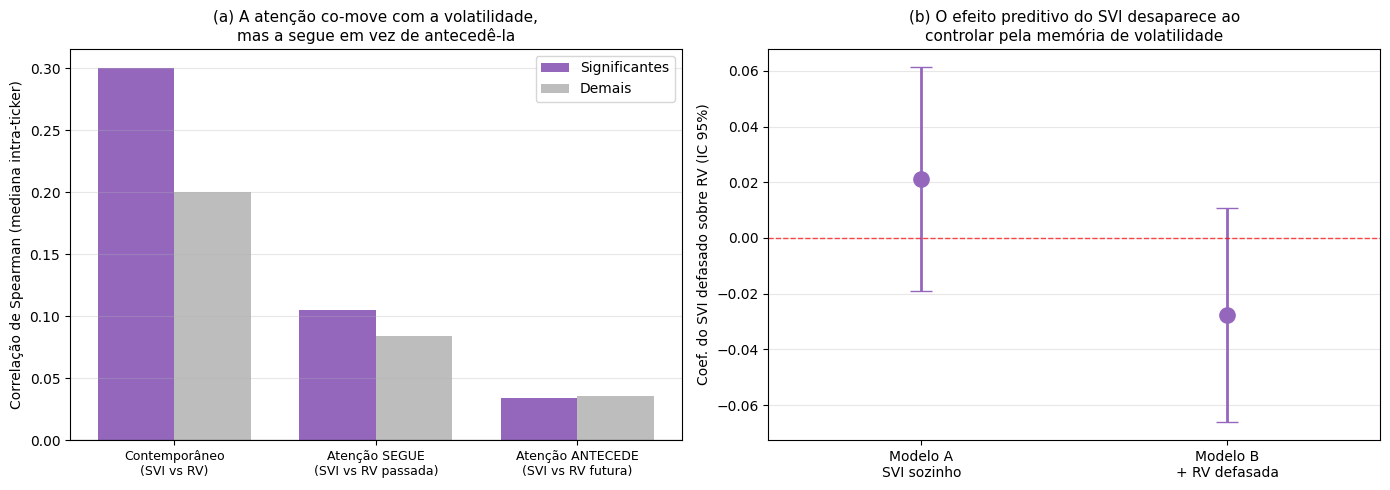

In [17]:
# ── Figura: a atenção segue a volatilidade e é redundante com o eGARCH ───
COR_SVI, COR_RESTO = "#9467bd", "#bdbdbd"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) estrutura lead-lag das correlações SVI x RV
cats = ["Contemporâneo\n(SVI vs RV)", "Atenção SEGUE\n(SVI vs RV passada)", "Atenção ANTECEDE\n(SVI vs RV futura)"]
x, w = np.arange(3), 0.38
ax1.bar(x - w/2, med.loc["significantes"], w, label="Significantes", color=COR_SVI)
ax1.bar(x + w/2, med.loc["resto"],         w, label="Demais",        color=COR_RESTO)
ax1.set_xticks(x); ax1.set_xticklabels(cats, fontsize=9)
ax1.set_ylabel("Correlação de Spearman (mediana intra-ticker)")
ax1.set_title("(a) A atenção co-move com a volatilidade,\nmas a segue em vez de antecedê-la", fontsize=11)
ax1.axhline(0, color="black", lw=0.8); ax1.legend(); ax1.grid(True, axis="y", alpha=0.3)

# (b) colapso do coeficiente do SVI ao controlar pela volatilidade defasada
coefs = [m_a.params["svild_z_lag1"], m_b.params["svild_z_lag1"]]
ca, cb = m_a.conf_int().loc["svild_z_lag1"], m_b.conf_int().loc["svild_z_lag1"]
err = np.array([[coefs[0]-ca[0], coefs[1]-cb[0]], [ca[1]-coefs[0], cb[1]-coefs[1]]])
ax2.errorbar([0, 1], coefs, yerr=err, fmt="o", ms=11, capsize=8, lw=2, color=COR_SVI)
ax2.axhline(0, color="red", ls="--", lw=1, alpha=0.7)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Modelo A\nSVI sozinho", "Modelo B\n+ RV defasada"])
ax2.set_xlim(-0.5, 1.5); ax2.set_ylabel("Coef. do SVI defasado sobre RV (IC 95%)")
ax2.set_title("(b) O efeito preditivo do SVI desaparece ao\ncontrolar pela memória de volatilidade", fontsize=11)
ax2.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusão.** As três peças sustentam a mesma leitura. A atenção do investidor co-move com a volatilidade contemporânea (mediana $\rho \approx 0{,}30$ nos significantes vs. $0{,}20$ nos demais) e **segue** a volatilidade passada muito mais do que antecede a futura ($0{,}12$ contra $0{,}03$; Wilcoxon $p < 10^{-5}$). Como consequência, ao controlar pela volatilidade defasada — exatamente a dinâmica de persistência que o eGARCH já internaliza —, o coeficiente preditivo do SVI sobre a RV **cai ~97% e perde a significância** ($t \approx 0{,}1$). O controle aqui é apenas um defasamento de RV; o eGARCH captura a persistência de forma ainda mais rica (via $\beta\,\ln\sigma^2_{t-1}$ e o termo de magnitude $|z|$), de modo que a redundância é, no mínimo, tão forte quanto a aqui evidenciada. O SVI, sendo um reflexo defasado do próprio processo de volatilidade, não adiciona informação — o que explica a exclusão do eGARCH-X (M2) do Model Confidence Set.